<a href="https://colab.research.google.com/github/arpita-png/pattern-recognition-project/blob/main/Copy_of_Untitled3_last.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# upload → unzip → cd → install → fix path → run
from google.colab import files
uploaded = files.upload()


Saving Pattern_Recognition_Classical_Face_Project.zip to Pattern_Recognition_Classical_Face_Project.zip


In [ ]:
!unzip Pattern_Recognition_Classical_Face_Project.zip

In [ ]:
# move into the project folder
%cd Pattern_Recognition_Classical_Face_Project

/content/Pattern_Recognition_Classical_Face_Project


In [ ]:
!ls

configs    README.md  requirements.txt	    src
notebooks  reports    results_pr_classical


In [ ]:
!cat requirements.txt

numpy>=1.23
pandas>=1.5
scikit-learn>=1.2
scipy>=1.10
matplotlib>=3.7
Pillow>=9.4
PyYAML>=6.0


In [ ]:
#!pip install -r requirements.txt

In [ ]:
# recognize the src package
import sys
import os
(sys.path.append(os.getcwd())) # does NOT return value
print(sys.path) # path was added successfully if printed

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/Pattern_Recognition_Classical_Face_Project']


In [ ]:
# run the program
!python -m src.main

Output directory: results_pr_classical/2026_05_05_224304
Finished: gaussian_nb_no_pca
Finished: linear_svm_no_pca
Finished: rbf_svm_no_pca
Finished: knn_no_pca
Finished: gaussian_nb_pca_50
Finished: linear_svm_pca_50
Finished: rbf_svm_pca_50
Finished: knn_pca_50
Finished: gaussian_nb_pca_100
Finished: linear_svm_pca_100
Finished: rbf_svm_pca_100
Finished: knn_pca_100
Finished: gaussian_nb_pca_0.95
Finished: linear_svm_pca_0.95
Finished: rbf_svm_pca_0.95
Finished: knn_pca_0.95

Done. Important files:
- results_pr_classical/2026_05_05_224304/metrics_all.csv
- results_pr_classical/2026_05_05_224304/tables/clean_test_ranking.csv
- results_pr_classical/2026_05_05_224304/classification_reports
- results_pr_classical/2026_05_05_224304/confusion_matrices


In [ ]:
import os
os.getcwd()

'/content/Pattern_Recognition_Classical_Face_Project'

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

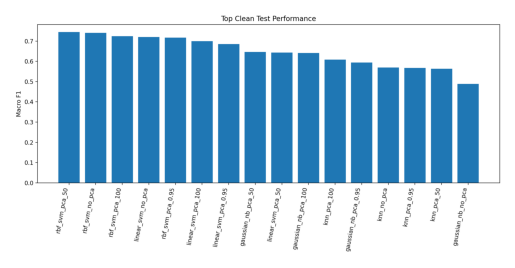

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("results_pr_classical/2026_05_05_224304/plots/top_clean_test_macro_f1.png")

plt.imshow(img)
plt.axis('off')

In [ ]:
import pandas as pd
import os

base = "results_pr_classical"
latest = sorted(os.listdir(base))[-1]
path = os.path.join(base, latest)

df = pd.read_csv(os.path.join(path, "metrics_all.csv"))

# Only clean test data
clean_df = df[(df["degradation"] == "clean") & (df["split"] == "test")].copy()

# Correct column
clean_df["model_setting"] = clean_df["experiment_name"]

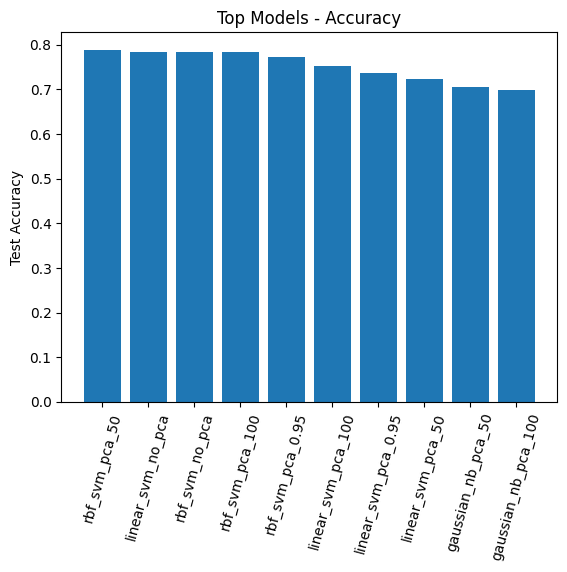

In [ ]:
import matplotlib.pyplot as plt

top = clean_df.sort_values("accuracy", ascending=False).head(10)

plt.figure()
plt.bar(top["model_setting"], top["accuracy"])
plt.xticks(rotation=75)
plt.ylabel("Test Accuracy")
plt.title("Top Models - Accuracy")
plt.show()

In [ ]:
print(df.columns.tolist())

['experiment_name', 'split', 'degradation', 'degradation_name', 'degradation_params', 'inference_ms_per_sample', 'accuracy', 'balanced_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'dataset', 'model_name', 'pca_components', 'train_size', 'eval_size', 'num_classes', 'tuning_info']


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

base = "results_pr_classical"
latest = sorted(os.listdir(base))[-1]
path = os.path.join(base, latest)

df = pd.read_csv(os.path.join(path, "metrics_all.csv"))

clean_df = df[(df["degradation"] == "clean") & (df["split"] == "test")].copy()

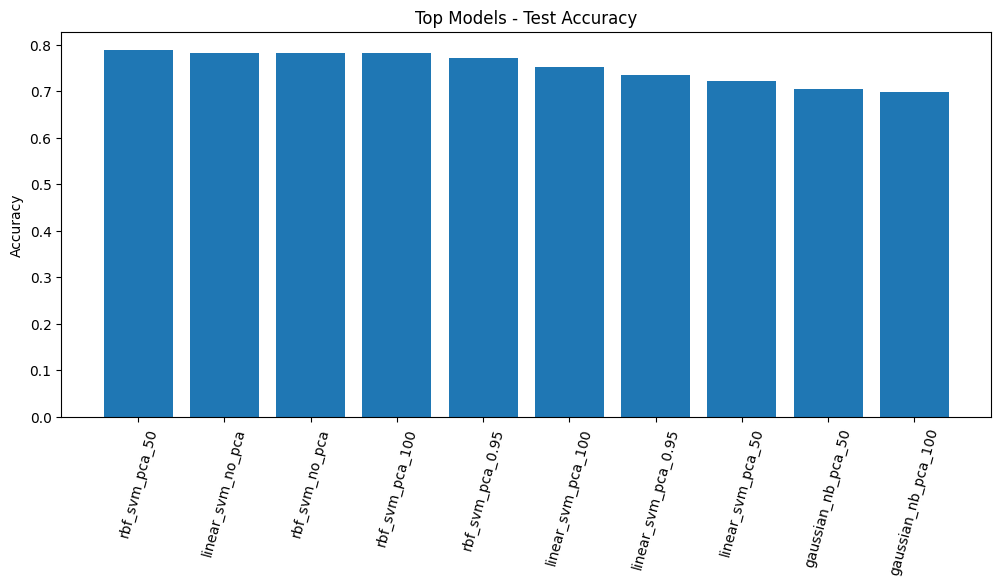

In [ ]:
top = clean_df.sort_values("accuracy", ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(top["experiment_name"], top["accuracy"])
plt.xticks(rotation=75)
plt.ylabel("Accuracy")
plt.title("Top Models - Test Accuracy")
plt.show()

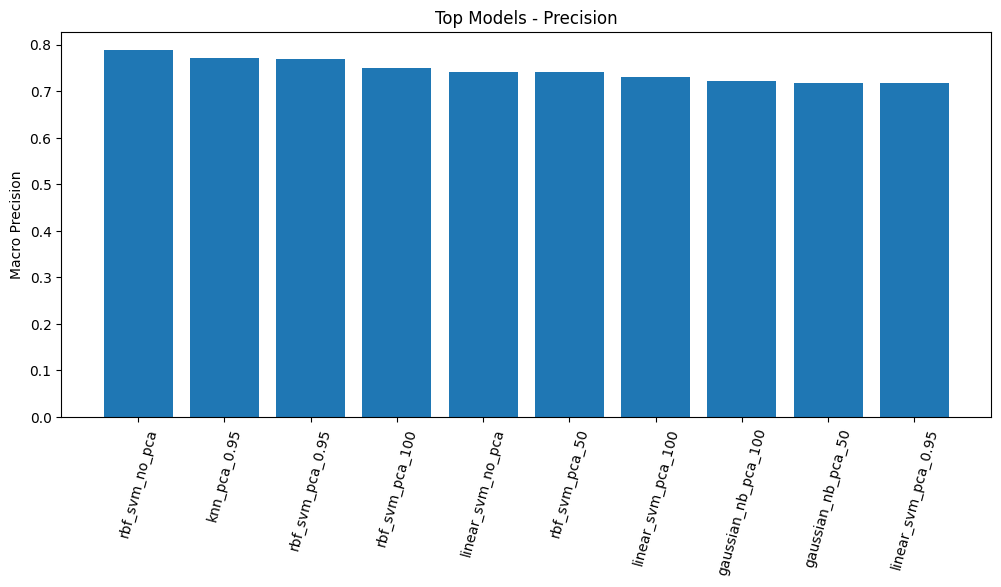

In [ ]:
top = clean_df.sort_values("macro_precision", ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(top["experiment_name"], top["macro_precision"])
plt.xticks(rotation=75)
plt.ylabel("Macro Precision")
plt.title("Top Models - Precision")
plt.show()

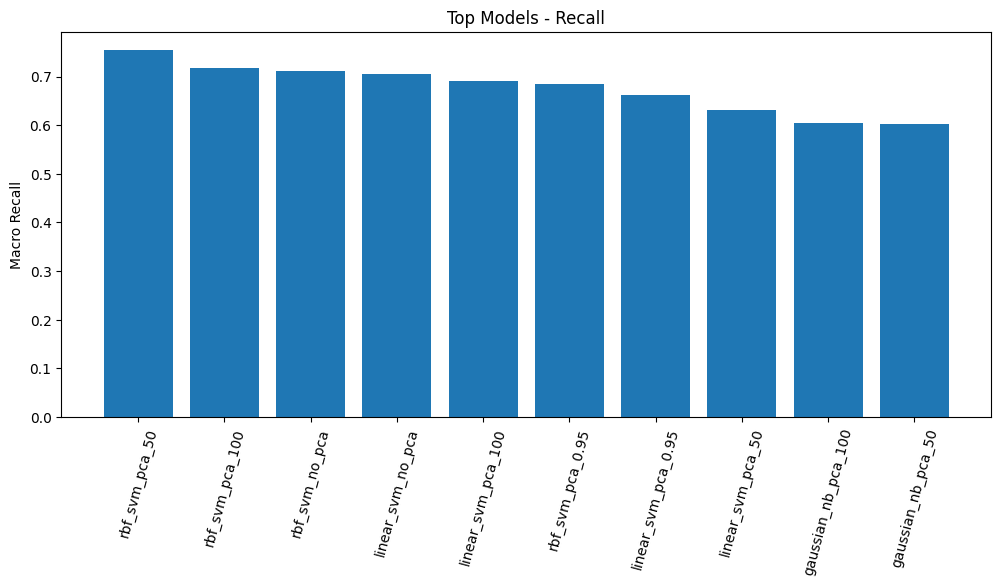

In [ ]:
top = clean_df.sort_values("macro_recall", ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(top["experiment_name"], top["macro_recall"])
plt.xticks(rotation=75)
plt.ylabel("Macro Recall")
plt.title("Top Models - Recall")
plt.show()

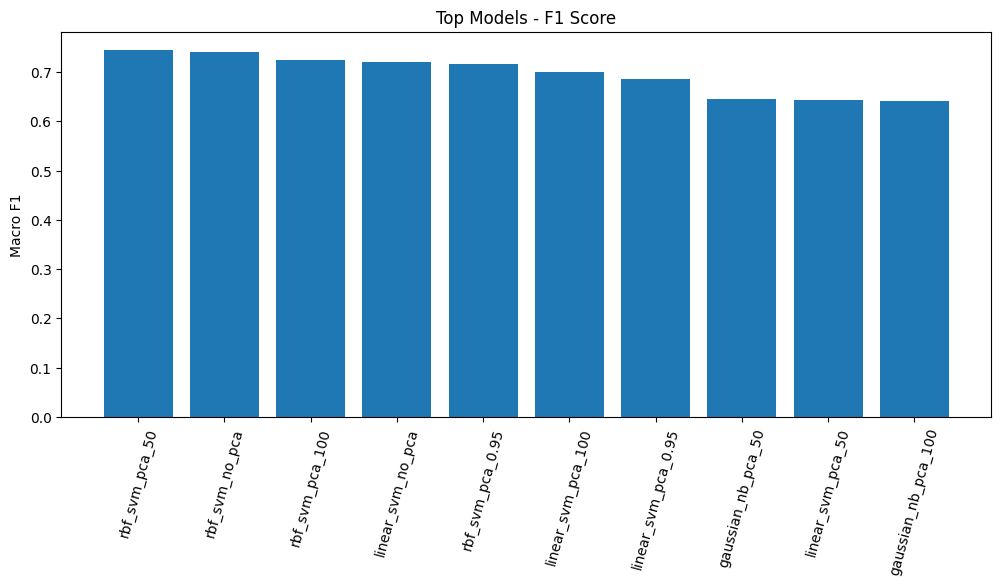

In [ ]:
top = clean_df.sort_values("macro_f1", ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(top["experiment_name"], top["macro_f1"])
plt.xticks(rotation=75)
plt.ylabel("Macro F1")
plt.title("Top Models - F1 Score")
plt.show()

Best model: rbf_svm_pca_50


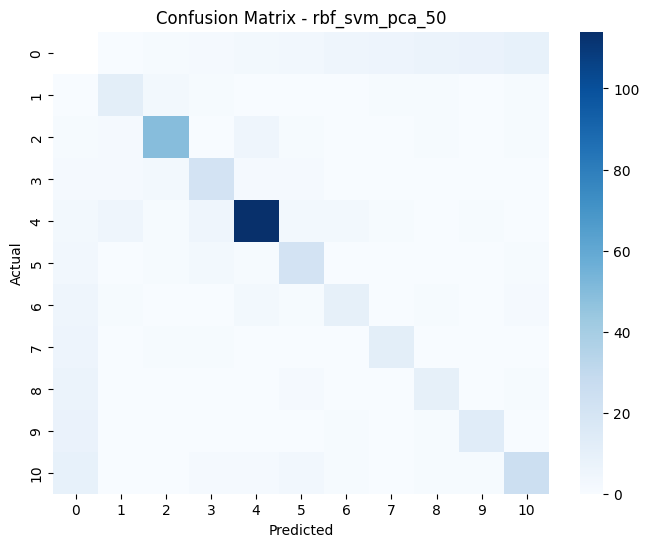

In [ ]:
best_model = clean_df.sort_values("macro_f1", ascending=False).iloc[0]["experiment_name"]
print("Best model:", best_model)

cm_path = os.path.join(
    path,
    "confusion_matrices",
    f"{best_model}_clean_confusion_matrix.csv"
)

cm = pd.read_csv(cm_path, header=None)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

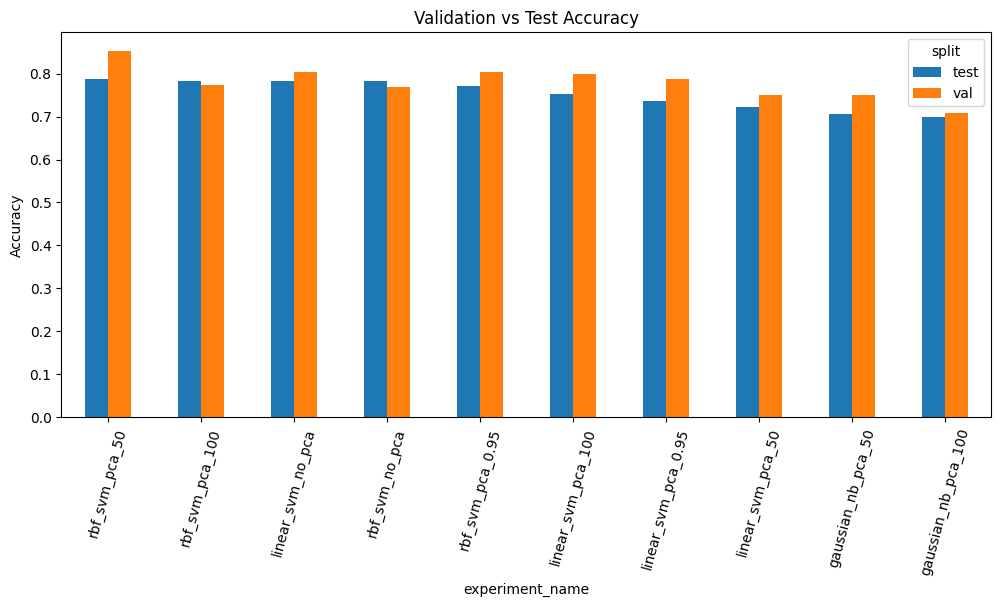

In [ ]:
clean_val_test = df[(df["degradation"] == "clean") & (df["split"].isin(["val", "test"]))].copy()

pivot = clean_val_test.pivot(index="experiment_name", columns="split", values="accuracy")
pivot = pivot.sort_values("test", ascending=False).head(10)

pivot.plot(kind="bar", figsize=(12,5))
plt.ylabel("Accuracy")
plt.title("Validation vs Test Accuracy")
plt.xticks(rotation=75)
plt.show()

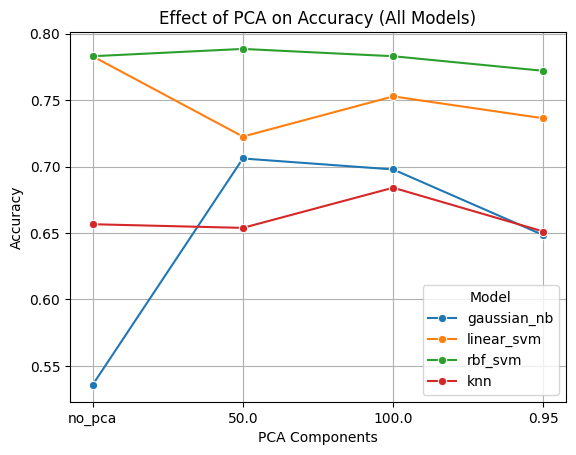

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
base = "results_pr_classical"
latest = sorted(os.listdir(base))[-1]
path = os.path.join(base, latest)

df = pd.read_csv(os.path.join(path, "metrics_all.csv"))

# Filter clean test data
clean_df = df[(df["degradation"] == "clean") & (df["split"] == "test")].copy()

# Convert PCA values to string (handle NaN)
clean_df["pca_components"] = clean_df["pca_components"].fillna("no_pca").astype(str)

# Plot
plt.figure()

sns.lineplot(
    data=clean_df,
    x="pca_components",
    y="accuracy",
    hue="model_name",
    marker="o"
)

plt.xlabel("PCA Components")
plt.ylabel("Accuracy")
plt.title("Effect of PCA on Accuracy (All Models)")
plt.legend(title="Model")
plt.grid()

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')